# Exercise 07: Approximate Bayesian Computation (ABC)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=42)

---

## Question 1 — ABC-MCMC for a Gaussian Mean

### Background

Plain rejection-sampling ABC is wasteful: most proposed parameters are thrown away. **ABC-MCMC** fixes this by using a Markov chain to propose parameters that are already near promising regions of the prior, rather than sampling blindly.

The algorithm works as follows:

1. Start from an initial parameter value $\theta^{(1)}$.
2. At each step $t$, propose a new value $\theta^{(p)}$ from a symmetric Gaussian kernel centred at the current state: $\theta^{(p)} \sim \mathcal{N}(\theta^{(t)},\, \sigma_\text{prop}^2)$.
3. Simulate data $y^{(p)} \sim p(y \mid \theta^{(p)})$ and compute the summary statistic $T(y^{(p)})$.
4. **If** $d(T(y^{(p)}),\, T(\tilde{y})) \le \epsilon$, compute the Metropolis acceptance probability
$$\alpha = \min\!\left(1,\; \frac{p(\theta^{(p)})}{p(\theta^{(t)})}\right)$$
   and accept $\theta^{(p)}$ with probability $\alpha$; otherwise stay at $\theta^{(t)}$.
5. **Else** (distance too large), automatically stay at $\theta^{(t)}$.
6. Discard the first $t^*$ draws as **warm-up**.

Because the proposal is symmetric, the proposal ratio cancels and only the prior ratio remains.

### Model

$$\mu \sim \mathcal{N}(0, 1) \qquad y_i \mid \mu \sim \mathcal{N}(\mu, 1), \quad i = 1, \ldots, N$$

The **sufficient summary statistic** for $\mu$ is the sample mean $T(y) = \bar{y}$, so the distance is simply $|\bar{y}^{(p)} - \bar{\tilde{y}}|$.

The **analytic posterior** is $\mu \mid \tilde{y} \sim \mathcal{N}\!\left(\frac{N\bar{\tilde{y}}}{N+1},\, \frac{1}{N+1}\right)$.

In [3]:
def abc_mcmc(
    y_obs,          # 1-D array of observed data
    n_draws,        # total number of MCMC steps
    epsilon,        # acceptance threshold on |T_sim - T_obs|
    sigma_prop,     # std of the Gaussian random-walk proposal
    warmup,         # number of initial draws to discard
    rng,            # numpy random generator
):

    N = len(y_obs)
    T_obs = np.mean(y_obs)          # observed summary statistic

    # initialise the chain at a prior draw that already passes the ABC gate
    while True:
        theta_current = rng.normal(0, 1)
        y_init = rng.normal(theta_current, 1, size=N)
        if abs(np.mean(y_init) - T_obs) <= epsilon:
            break

    chain = []

    for t in range(n_draws):

        theta_proposed = rng.normal(theta_current, sigma_prop)

        y_sim = rng.normal(theta_proposed, 1, size=N)

        T_sim = np.mean(y_sim)

        # check the ABC acceptance criterion
        if abs(T_sim - T_obs) <= epsilon:
            log_prior_proposed = stats.norm.logpdf(theta_proposed, 0, 1)
            log_prior_current  = stats.norm.logpdf(theta_current,  0, 1)
            log_alpha = log_prior_proposed - log_prior_current

            if np.log(rng.uniform()) < log_alpha:
                theta_current = theta_proposed
            # else: stay at theta_current (no explicit action needed)

        # else: distance too large → stay at theta_current

        chain.append(theta_current)

    return np.array(chain[warmup:])


#### 1a — Small dataset ($N = 5$)

Generate 5 observations from $\mathcal{N}(\mu=1, 1)$, run ABC-MCMC, and overlay the analytic posterior.

Observed data: [2.043 1.24  0.96  1.326 1.027]
Sample mean:   1.319
Posterior draws retained: 28000


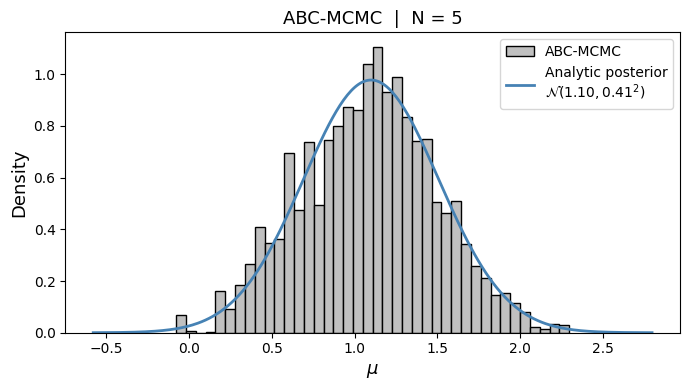

In [6]:
# generate observed data
mu_true = 1.0
N = 5
y_obs = rng.normal(mu_true, 1, size=N)
print(f"Observed data: {y_obs.round(3)}")
print(f"Sample mean:   {y_obs.mean():.3f}")

# run ABC-MCMC
chain_5 = abc_mcmc(
    y_obs     = y_obs,
    n_draws   = 30_000,
    epsilon   = 0.15,
    sigma_prop= 0.5,
    warmup    = 2_000,
    rng       = rng,
)
print(f"Posterior draws retained: {len(chain_5)}")

# analytic posterior
post_mean = N * y_obs.mean() / (N + 1)
post_std  = 1 / np.sqrt(N + 1)
mu_grid   = np.linspace(chain_5.min() - 0.5, chain_5.max() + 0.5, 300)

# plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(chain_5, bins=40, density=True, color="silver", edgecolor="black", label="ABC-MCMC")
ax.plot(mu_grid, stats.norm.pdf(mu_grid, post_mean, post_std),
        "steelblue", lw=2, label=f"Analytic posterior\n$\\mathcal{{N}}({post_mean:.2f}, {post_std:.2f}^2)$")
ax.set_xlabel("$\\mu$", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(f"ABC-MCMC  |  N = {N}", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

#### 1b — Larger dataset ($N = 50$)

Repeat with $N = 50$ observations. Because the posterior is now much narrower, you will need a tighter $\epsilon$ and a smaller proposal $\sigma_\text{prop}$. Observe how the chain still mixes without catastrophic rejection rates — a key advantage over plain rejection sampling.

Posterior draws retained: 28000


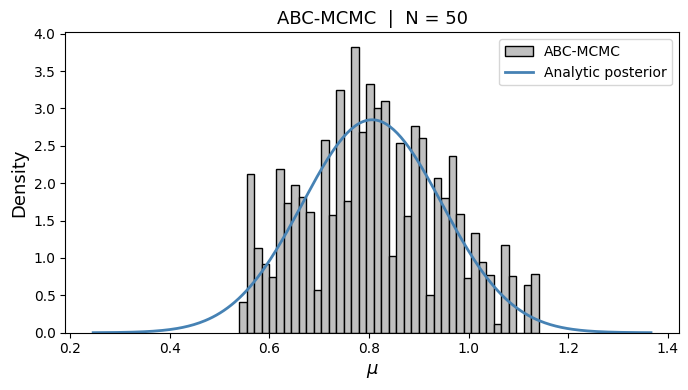

In [7]:
N2 = 50
y_obs2 = rng.normal(mu_true, 1, size=N2)

chain_50 = abc_mcmc(
    y_obs     = y_obs2,
    n_draws   = 30_000,
    epsilon   = 0.005,
    sigma_prop= 0.15,
    warmup    = 2_000,
    rng       = rng,
)
print(f"Posterior draws retained: {len(chain_50)}")

post_mean2 = N2 * y_obs2.mean() / (N2 + 1)
post_std2  = 1 / np.sqrt(N2 + 1)
mu_grid2   = np.linspace(post_mean2 - 4*post_std2, post_mean2 + 4*post_std2, 300)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(chain_50, bins=40, density=True, color="silver", edgecolor="black", label="ABC-MCMC")
ax.plot(mu_grid2, stats.norm.pdf(mu_grid2, post_mean2, post_std2),
        "steelblue", lw=2, label=f"Analytic posterior")
ax.set_xlabel("$\\mu$", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(f"ABC-MCMC  |  N = {N2}", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

#### 1c — Trace plot and acceptance diagnostics

A healthy MCMC chain should mix well — moving freely across the posterior without getting stuck. Plot the trace of the chain from **1b** and report the fraction of steps where a new proposal was accepted (acceptance rate). A rate between roughly 20 % and 50 % is typical for a well-tuned random-walk sampler.

Acceptance rate: 16.0%


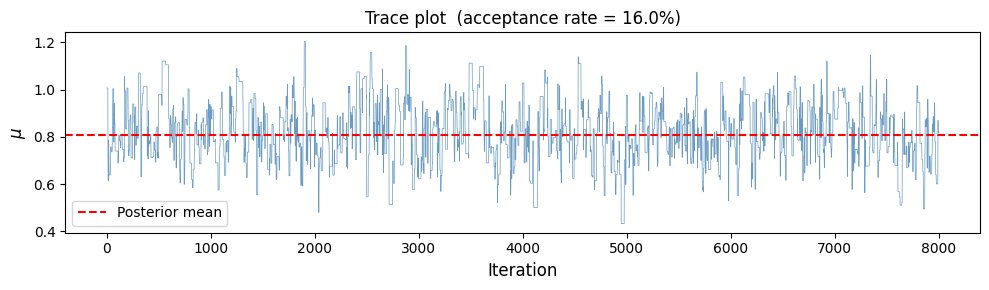

In [ ]:
chain_full = abc_mcmc(
    y_obs     = y_obs2,
    n_draws   = 10_000,
    epsilon   = 0.05,
    sigma_prop= 0.15,
    warmup    = 2000,     
    rng       = rng,
)

# acceptance rate: proportion of steps where the chain moved
acceptance_rate = np.mean(np.diff(chain_full) != 0)
print(f"Acceptance rate: {acceptance_rate:.1%}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(chain_full, lw=0.5, color="steelblue", alpha=0.8)
ax.axhline(post_mean2, color="red", lw=1.5, linestyle="--", label="Posterior mean")
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("$\\mu$", fontsize=12)
ax.set_title(f"Trace plot  (acceptance rate = {acceptance_rate:.1%})", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

#### Discussion

1. What happens to the chain if $\epsilon$ is set very large (e.g. $\epsilon = 10$)? What about very small ($\epsilon = 0.001$)?  
2. Why does plain rejection-sampling ABC become impractical as $N$ grows, even when you use the sufficient summary statistic?

**Discussion answers**

1. **Large $\epsilon$:** Almost every proposal passes the ABC gate, so the chain behaves like a plain Metropolis sampler on the prior — the posterior will be over-dispersed (too wide), converging to something between the prior and the true posterior.
   **Small $\epsilon$:** Nearly all proposals are rejected at the ABC gate; the chain barely moves, giving very high auto-correlation and poor mixing. In the limit $\epsilon \to 0$ with a sufficient summary statistic, it converges to the exact posterior — but the computational cost becomes prohibitive.

2. With plain rejection sampling, the probability of $|\bar{y}^{(p)} - \bar{\tilde{y}}| \le \epsilon$ scales roughly as $\epsilon / (1/\sqrt{N}) = \epsilon\sqrt{N}^{-1}$, so for fixed $\epsilon$ the acceptance rate *falls* as $N$ grows even with the sufficient statistic. This means exponentially more prior draws are needed to collect enough posterior samples. ABC-MCMC avoids this collapse by proposing *locally* — it only moves the chain slightly from regions already near the posterior.

---

## Question 2 — ABC with Summary Statistics: Sufficient vs. Insufficient

### Background

When data are high-dimensional, comparing full datasets point-by-point leads to catastrophic rejection rates. The fix is to compress data into a small set of **summary statistics** $T(y)$ and accept whenever
$$d(T(y^{(t)}),\, T(\tilde{y})) \le \epsilon.$$

This is exact (i.e. gives the true posterior) only if $T$ is **sufficient** for $\theta$. Otherwise you get a biased approximation. 

In this question you will compare three choices of summary statistic:

| Label | Summary statistic $T(y)$ | Sufficient? |
|-------|--------------------------|-------------|
| **A** | sample mean $\bar{y}$ | ✅ Yes |
| **B** | sample median | ❌ No |
| **C** | first observation $y_1$ only | ❌ No |

### Model

Same Gaussian mean model as Question 1:
$$\mu \sim \mathcal{N}(0, 1), \qquad y_i \mid \mu \sim \mathcal{N}(\mu, 1).$$


In [11]:
def abc_rejection_summary(
    y_obs,
    summary_fn,
    n_prior,
    epsilon,
    rng,
):
    N = len(y_obs)
    T_obs = summary_fn(y_obs)

    mu_prior = rng.normal(0, 1, size=n_prior)

    y_sim = mu_prior[:, None] + rng.normal(0, 1, size=(n_prior, N))

    T_sim = np.apply_along_axis(summary_fn, axis=1, arr=y_sim)

    accepted = mu_prior[np.abs(T_sim - T_obs) <= epsilon]

    return accepted

#### 2a — Compare three summary statistics

We use $N = 20$ observations drawn from $\mathcal{N}(\mu=1, 1)$ and run ABC three times — once per summary statistic. All three runs use the same prior draws, $\epsilon$, and number of simulations.

Analytic posterior: N(1.020, 0.218^2)
A: sample mean (sufficient): 8986 accepted draws  |  mean = 1.017  std = 0.226
B: sample median: 9931 accepted draws  |  mean = 0.895  std = 0.269
C: first obs only: 10456 accepted draws  |  mean = 0.269  std = 0.710


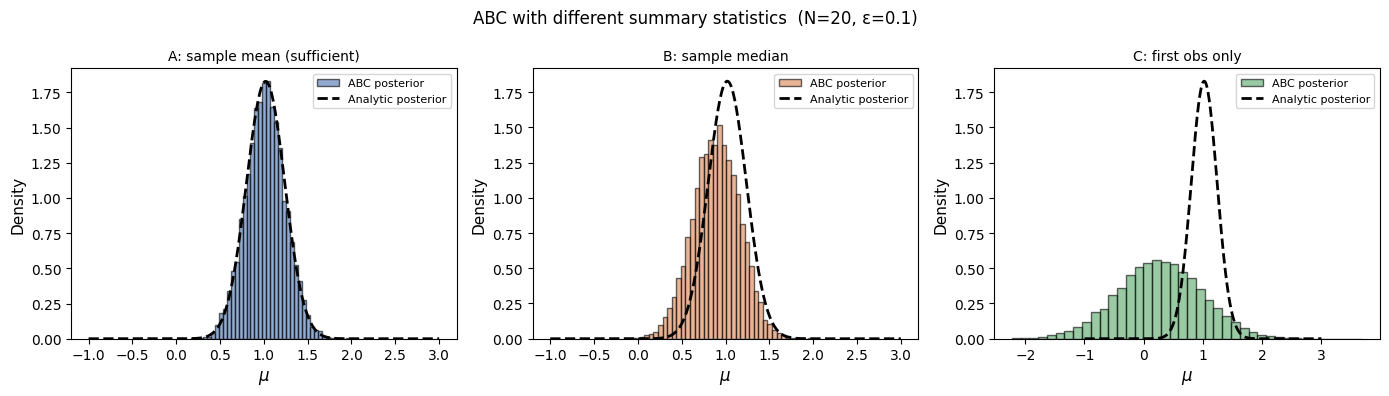

In [12]:
# observed data
N = 20
mu_true = 1.0
y_obs = rng.normal(mu_true, 1, size=N)

# analytic posterior
post_mean = N * y_obs.mean() / (N + 1)
post_std  = 1 / np.sqrt(N + 1)
print(f"Analytic posterior: N({post_mean:.3f}, {post_std:.3f}^2)")

# summary statistics
summaries = {
    "A: sample mean (sufficient)": np.mean,
    "B: sample median": np.median,
    "C: first obs only": lambda y: y[0],
}

N_PRIOR = 200_000
EPSILON = 0.1

results = {}
for label, fn in summaries.items():
    post = abc_rejection_summary(
        y_obs      = y_obs,
        summary_fn = fn,
        n_prior    = N_PRIOR,
        epsilon    = EPSILON,
        rng        = rng,
    )
    results[label] = post
    print(f"{label}: {len(post)} accepted draws  |  "
          f"mean = {post.mean():.3f}  std = {post.std():.3f}")

# plot
mu_grid = np.linspace(-1, 3, 400)
analytic_pdf = stats.norm.pdf(mu_grid, post_mean, post_std)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, (label, post), color in zip(axes, results.items(), colors):
    if len(post) > 0:
        ax.hist(post, bins=40, density=True,
                color=color, alpha=0.6, edgecolor="black", label="ABC posterior")
    ax.plot(mu_grid, analytic_pdf, "k", lw=2, linestyle="--", label="Analytic posterior")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("$\\mu$", fontsize=12)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle(f"ABC with different summary statistics  (N={N}, ε={EPSILON})", fontsize=12)
plt.tight_layout()
plt.show()

#### 2b — Effect of $\epsilon$ on the sufficient-statistic posterior

Using summary **A** (sample mean), vary $\epsilon \in \{0.5,\, 0.15,\, 0.05\}$ and overlay the resulting ABC posteriors on one plot. This reproduces the qualitative experiment from the lecture slides.

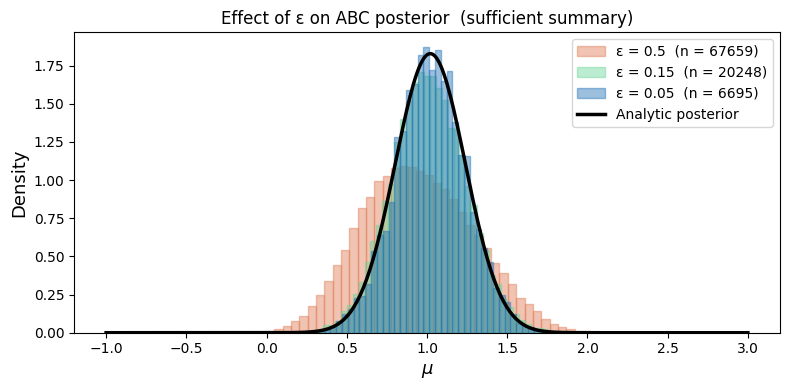

In [13]:
epsilons = [0.5, 0.15, 0.05]

fig, ax = plt.subplots(figsize=(8, 4))
palette = ["#e07b54", "#6bd699", "#2171b5"]

for eps, col in zip(epsilons, palette):
    post = abc_rejection_summary(
        y_obs      = y_obs,
        summary_fn = np.mean,
        n_prior    = 300_000,
        epsilon    = eps,
        rng        = rng,
    )
    ax.hist(post, bins=50, density=True, alpha=0.45, color=col,
            edgecolor=col, label=f"ε = {eps}  (n = {len(post)})")

ax.plot(mu_grid, analytic_pdf, "k", lw=2.5, label="Analytic posterior")
ax.set_xlabel("$\\mu$", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title("Effect of ε on ABC posterior  (sufficient summary)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

#### Discussion

1. Panels B and C both use insufficient statistics. Do their posteriors differ from the analytic one in the same way, or differently? Explain *why* each one is biased or inefficient.
2. Looking at experiment 2b, describe the bias-variance trade-off when choosing $\epsilon$: what does a large $\epsilon$ sacrifice, and what does a very small $\epsilon$ sacrifice in practice?

**Discussion answers**

1. **B (median):** The posterior is centred near the correct value but is *wider* than the analytic one. The median discards information about the spread of the data, so the posterior retains extra uncertainty.
   **C (first observation only):** The posterior is centred at the right location but is *much* wider — essentially it recovers a posterior for $\mu$ with only $N=1$ effective observation, regardless of how large $N$ is. A single observation is the most extreme case of an insufficient statistic: it ignores all remaining data.

2. **Large $\epsilon$:** Many draws are accepted, giving a smooth posterior estimate — but it is *biased*: the ABC posterior is a blurred version of the true posterior because samples with quite different parameters are accepted as long as their summaries are within $\epsilon$. The approximation error is large.
   **Small $\epsilon$:** The posterior bias shrinks toward zero (converging to the true posterior as $\epsilon \to 0$), but the acceptance rate plummets. In practice you need vastly more prior draws to collect enough accepted samples, making the algorithm computationally expensive (high variance in the MC estimate).